# 🟢 PROJECT · Easy · Mall k-Sweep Silhouette Study

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Sweep k=2..10 with silhouette scores and READ the numbers
2. Draw side-by-side silhouette diagrams for k=3, 5, 7 and compare their
   anatomy visually
3. Pick a winner with evidence, then profile its segments

**Business question:** *how many customer segments does the mall data really
support?* Not "what does k=5 give" - we let the evaluation decide.

In [1]:
# ---- Setup ------------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up to course root '02_machine_learning'; download-once helper."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv", fpath)
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")

mall_path = get_data("mall_customers.csv", MALL_URL)
if not mall_path.exists():
    urllib.request.urlretrieve(MALL_URL, mall_path)

## 1. Load & scale once (identical coordinates for every candidate)

In [2]:
mall = pd.read_csv(mall_path)
feat_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()
X = scaler.fit_transform(mall[feat_cols])
print(f"{len(mall)} customers scaled on {feat_cols}")

200 customers scaled on ['Annual Income (k$)', 'Spending Score (1-100)']


## 2. The sweep - one number per k

In [3]:
ks = range(2, 11)
scores, label_bank = [], {}
for k in ks:                                        # refit + rescore each candidate
    lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    scores.append(silhouette_score(X, lab))
    label_bank[k] = lab                             # keep for diagrams below

sweep = pd.DataFrame({"k": list(ks), "mean_silhouette": np.round(scores, 3)})
display(sweep)                                      # noqa: F821
best_k = int(sweep.loc[sweep.mean_silhouette.idxmax(), "k"])
print(f"\nnumeric winner: k={best_k} ({max(scores):.3f})")

,k,mean_silhouette
0,2,0.321
1,3,0.467
2,4,0.494
3,5,0.555
4,6,0.540
5,7,0.528
6,8,0.455
7,9,0.457
8,10,0.443



numeric winner: k=5 (0.555)


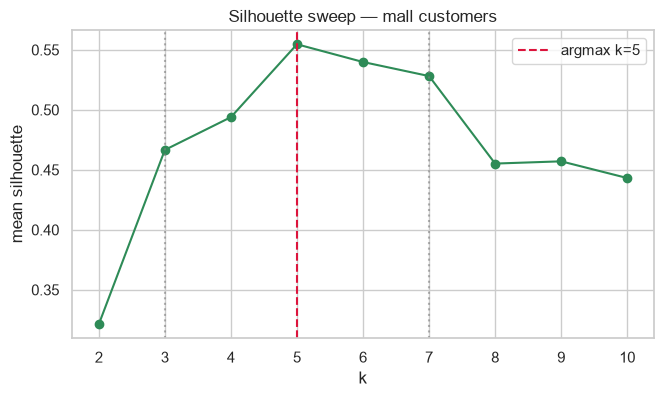

In [4]:
plt.figure(figsize=(7.5, 4))                        # the decision curve
plt.plot(list(ks), scores, marker="o", color="seagreen")
plt.axvline(best_k, ls="--", color="crimson",
            label=f"argmax k={best_k}")
for k in (3, 7):                                    # mark our comparison trio too
    plt.axvline(k, ls=":", color="grey", alpha=0.6)
plt.xlabel("k"); plt.ylabel("mean silhouette"); plt.legend()
plt.title("Silhouette sweep - mall customers"); plt.show()

## 3. Diagram anatomy contest - k=3 vs k=5 vs k=7

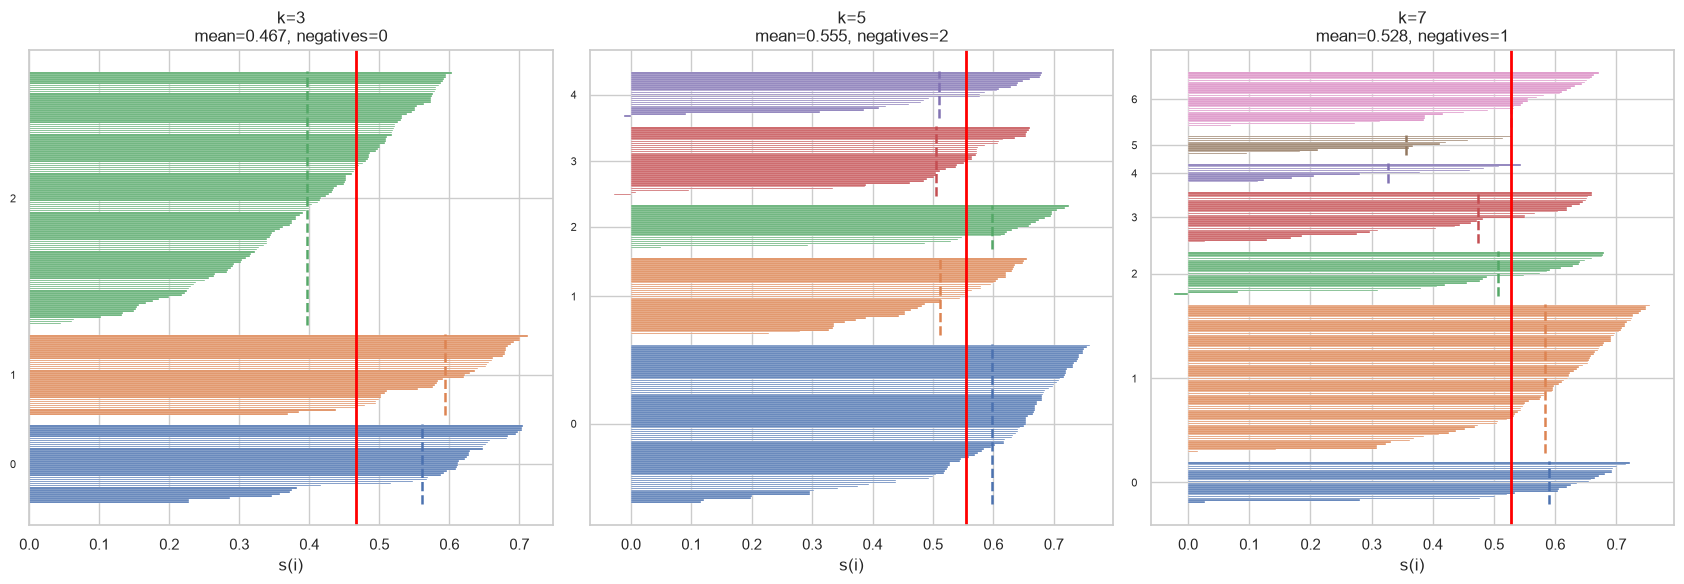

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
pal = sns.color_palette("deep", max(label_bank[7]) + 1)   # shared colour bank


def draw(labels, ax, title):
    """Compact version of the classic diagram for a grid cell."""
    samples = silhouette_samples(X, labels)
    y_pos, ticks, labs = 0, [], []
    for c, cl in enumerate(sorted(np.unique(labels))):
        vals = np.sort(samples[labels == cl])
        start = y_pos
        for v in vals:
            ax.barh(y_pos, v, height=0.85, color=pal[c],
                    edgecolor="white", linewidth=0.25)
            y_pos += 1
        ax.plot([vals.mean()] * 2, [start - 0.8, y_pos - 0.2],
                ls="--", color=pal[c], lw=1.8)      # cluster mean marker
        ticks.append((start + y_pos - 1) / 2)
        labs.append(str(cl))
        y_pos += 5                                  # gap between bands
    gm = float(samples.mean())
    ax.axvline(gm, color="red", lw=2)               # global mean reference
    ax.set_yticks(ticks); ax.set_yticklabels(labs, fontsize=8)
    ax.set_title(f"{title}\nmean={gm:.3f}, negatives={(samples < 0).sum()}")
    ax.set_xlabel("s(i)")


for ax, k in zip(axes, (3, 5, 7)):                  # three contenders, one look
    draw(label_bank[k], ax, f"k={k}")
plt.tight_layout(); plt.show()

Anatomy read-out:

- **k=3** - thick bands but the middle band is a forced merger of two real
  islands; some members sit far from home (visible short bars).
- **k=5** - bands match the actual islands; means hug the red line; almost no
  negative bars. The geometry's natural answer.
- **k=7** - fragmentation begins: thin slivers appear where K-Means splits
  single islands to satisfy k; mean drops accordingly.

💡 Numbers AND pictures agree: **k=5 wins** on this dataset.

## 4. Winner's reward - segment profiles

In [6]:
mall["cluster"] = label_bank[best_k]                 # attach winning labels
profile = (mall.groupby("cluster")
               .agg(size=("cluster", "size"),
                    age_mean=("Age", "mean"),
                    income_mean=("Annual Income (k$)", "mean"),
                    spend_mean=("Spending Score (1-100)", "mean"))
               .round(1))

def name_seg(r):                                     # marketer-readable naming
    inc = ("high-income" if r.income_mean >= 70 else
           "mid-income" if r.income_mean >= 40 else "low-income")
    spd = ("big-spender" if r.spend_mean >= 60 else
           "moderate" if r.spend_mean >= 40 else "careful")
    return f"{inc} {spd}"

profile["segment"] = profile.apply(name_seg, axis=1)
profile.sort_values("spend_mean", ascending=False)

,size,age_mean,income_mean,spend_mean,segment
cluster,,,,,
1,39,32.7,86.5,82.1,high-income big-spender
2,22,25.3,25.7,79.4,low-income big-spender
0,81,42.7,55.3,49.5,mid-income moderate
4,23,45.2,26.3,20.9,low-income careful
3,35,41.1,88.2,17.1,high-income careful


## Findings

- The sweep crowns **k=5** numerically; the diagram trio explains WHY - five
  matches the visible island count, while 3 under-splits and 7 over-splits.
- Winning segments mirror the K-Means module's story: two high-income groups
  (spenders vs careful), two low-income groups (enthusiasts vs careful), plus
  a mid-income middle.
- Evaluation-driven k selection worked WITHOUT peeking at any business
  preference - then business naming made it actionable.

⚠️ Limitations: two features only; silhouette favors convex blobs so exotic
shapes would need other judges; final segment names still require validation
against real campaign responses.